In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from sklearn.metrics import r2_score
from matplotlib.lines import Line2D
import scipy as sc

sys.path.append('/Users/kjesta/Desktop/LABDATA/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Processed_files/')

from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])



import warnings
warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

In [3]:
# Open processed files
from open_data import *

data20 = processed_data_20cm
data30 = processed_data_30cm

In [4]:
freqs30 = list(data30.keys())
volts30 = []

for i in range(len(freqs30)):
    volts30.append(list(data30[freqs30[i]].keys()))

In [5]:
freqs20 = list(data20.keys())
volts20 = []

for i in range(len(freqs20)):
    volts20.append(list(data20[freqs20[i]].keys()))

In [6]:
k30 = []
for f in freqs30:
    k30.append(estimate_wavenumber(f, 0.3))

k20 = []
for f in freqs20:
    k20.append(estimate_wavenumber(f, 0.3))

In [7]:
results = []

def find_amps(data, f, v, condition, k, D):
    if D == 0.3:
        H = 0.25
    else:
        H = 0.15

    eta_r1 = data[f][v][condition]["R1"]
    eta_r2 = data[f][v][condition]["R2"]
    eta_r3 = data[f][v][condition]["R3"]

    # Getting the time series for each probe & run
    P0_r1, P0_r2, P0_r3 = eta_r1["P_0"], eta_r2["P_0"], eta_r3["P_0"]
    P1_r1, P1_r2, P1_r3 = eta_r1["P_1"], eta_r2["P_1"], eta_r3["P_1"]
    P2_r1, P2_r2, P2_r3 = eta_r1["P_2"], eta_r2["P_2"], eta_r3["P_2"]
    P3_r1, P3_r2, P3_r3 = eta_r1["P_3"], eta_r2["P_3"], eta_r3["P_3"]

    # Masks where data is not NaN (use P0 to define time)
    mask_P0_r1 = ~P0_r1.isna()
    mask_P0_r2 = ~P0_r2.isna()
    mask_P0_r3 = ~P0_r3.isna()

    # Masks for P1–P3
    mask_P1_r1 = ~P1_r1.isna()
    mask_P1_r2 = ~P1_r2.isna()
    mask_P1_r3 = ~P1_r3.isna()

    mask_P2_r1 = ~P2_r1.isna()
    mask_P2_r2 = ~P2_r2.isna()
    mask_P2_r3 = ~P2_r3.isna()

    mask_P3_r1 = ~P3_r1.isna()
    mask_P3_r2 = ~P3_r2.isna()
    mask_P3_r3 = ~P3_r3.isna()

    # Convert to numpy & sign flip
    P0_r1 = -P0_r1[mask_P0_r1].values
    P0_r2 = -P0_r2[mask_P0_r2].values
    P0_r3 = -P0_r3[mask_P0_r3].values

    P1_r1 = -P1_r1[mask_P1_r1].values
    P1_r2 = -P1_r2[mask_P1_r2].values
    P1_r3 = -P1_r3[mask_P1_r3].values

    P2_r1 = -P2_r1[mask_P2_r1].values
    P2_r2 = -P2_r2[mask_P2_r2].values
    P2_r3 = -P2_r3[mask_P2_r3].values

    P3_r1 = -P3_r1[mask_P3_r1].values
    P3_r2 = -P3_r2[mask_P3_r2].values
    P3_r3 = -P3_r3[mask_P3_r3].values

    # Find peaks
    distance = (1 / f) * 250 * 0.8  # 80% of the period in samples

    def peak_amp(x, std):
        idx = sc.signal.find_peaks(x, height=(0.9 * np.sqrt(2) * std, 1.2 * np.sqrt(2) * std), distance=distance)[0]
        peaks = x[idx]
        peaks = peaks[peaks > 0]

        mean_amp = np.mean(peaks)
        std_amp = np.std(peaks, ddof=1)   # sample standard deviation
        n = len(peaks)
        err_amp = std_amp / np.sqrt(n)    # standard error
        return mean_amp, err_amp

    # Compute mean amplitude and SE for each probe & run
    amp_P0_r1, se_P0_r1 = peak_amp(P0_r1, np.nanstd(P0_r1))
    amp_P0_r2, se_P0_r2 = peak_amp(P0_r2, np.nanstd(P0_r2))
    amp_P0_r3, se_P0_r3 = peak_amp(P0_r3, np.nanstd(P0_r3))

    amp_P1_r1, se_P1_r1 = peak_amp(P1_r1, np.nanstd(P1_r1))
    amp_P1_r2, se_P1_r2 = peak_amp(P1_r2, np.nanstd(P1_r2))
    amp_P1_r3, se_P1_r3 = peak_amp(P1_r3, np.nanstd(P1_r3))

    amp_P2_r1, se_P2_r1 = peak_amp(P2_r1, np.nanstd(P2_r1))
    amp_P2_r2, se_P2_r2 = peak_amp(P2_r2, np.nanstd(P2_r2))
    amp_P2_r3, se_P2_r3 = peak_amp(P2_r3, np.nanstd(P2_r3))

    amp_P3_r1, se_P3_r1 = peak_amp(P3_r1, np.nanstd(P3_r1))
    amp_P3_r2, se_P3_r2 = peak_amp(P3_r2, np.nanstd(P3_r2))
    amp_P3_r3, se_P3_r3 = peak_amp(P3_r3, np.nanstd(P3_r3))

    # Compute decay rate
    probe_pos = [4.86, 6.69, 7.87, 9.15]
    alpha_r1, se_alpha_r1 = get_obs_damping_coeff([amp_P0_r1, amp_P1_r1, amp_P2_r1, amp_P3_r1], probe_pos)
    alpha_r2, se_alpha_r2 = get_obs_damping_coeff([amp_P0_r2, amp_P1_r2, amp_P2_r2, amp_P3_r2], probe_pos)
    alpha_r3, se_alpha_r3 = get_obs_damping_coeff([amp_P0_r3, amp_P1_r3, amp_P2_r3, amp_P3_r3], probe_pos)

    # Collect per-run rows
    runs = ["R1", "R2", "R3"]
    amps = [
        (amp_P0_r1, amp_P1_r1, amp_P2_r1, amp_P3_r1,
         se_P0_r1,  se_P1_r1,  se_P2_r1,  se_P3_r1),
        (amp_P0_r2, amp_P1_r2, amp_P2_r2, amp_P3_r2,
         se_P0_r2,  se_P1_r2,  se_P2_r2,  se_P3_r2),
        (amp_P0_r3, amp_P1_r3, amp_P2_r3, amp_P3_r3,
         se_P0_r3,  se_P1_r3,  se_P2_r3,  se_P3_r3),
    ]
    alpha = [alpha_r1, alpha_r2, alpha_r3]
    se_alpha = [se_alpha_r1, se_alpha_r2, se_alpha_r3]

    if D == 0.3:
        if v < 0.2:
            v_tag = 'low'
        if v >= 0.2 and v < 0.305:
            v_tag = 'medium'
        if v >= 0.370 and v < 0.385:
            v_tag = 'medium-high'
        if v >= 0.4:
            v_tag = 'high'

    else:
        if v == 0.1:
            v_tag = 'low'
        if v == 0.2:
            v_tag = 'medium'
        if v == 0.25:
            v_tag = 'medium-high'
        if v == 0.3:
            v_tag = 'high'
        
    for run, (a0, a1, a2, a3, e0, e1, e2, e3) in zip(runs, amps):
        results.append({
            "frequency": f,
            "volt": v,
            "volt_level": v_tag,
            "condition": condition,
            "run": run,
            "ak": a0 * k,
            "kH": k*D,
            "amp_P0": a0,
            "amp_P1": a1,
            "amp_P2": a2,
            "amp_P3": a3,
            "se_P0": e0,
            "se_P1": e1,
            "se_P2": e2,
            "se_P3": e3,
            "alpha": alpha[runs.index(run)],
            "se_alpha": se_alpha[runs.index(run)],
            "R": robin_parameter_eq_39(H=H, a=alpha[runs.index(run)], k=k)})


def process_condition(data, f, v, condition, k, D):
    find_amps(data, f, v, condition, k, D)

for i, f in enumerate(freqs20):
    k = estimate_wavenumber(f, 0.2)
    for v in volts20[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data20, f, v, condition="p005", k=k, D=0.2)
        process_condition(data20, f, v, condition="None", k=k, D=0.2)

df_20 = pd.DataFrame(results)

Frequency: 1.1, Voltage: 0.1
Frequency: 1.1, Voltage: 0.2
Frequency: 1.1, Voltage: 0.3
Frequency: 1.2, Voltage: 0.1
Frequency: 1.2, Voltage: 0.2
Frequency: 1.2, Voltage: 0.3
Frequency: 1.3, Voltage: 0.1
Frequency: 1.3, Voltage: 0.2
Frequency: 1.3, Voltage: 0.3
Frequency: 1.4, Voltage: 0.1
Frequency: 1.4, Voltage: 0.2
Frequency: 1.4, Voltage: 0.3
Frequency: 1.5, Voltage: 0.1
Frequency: 1.5, Voltage: 0.2
Frequency: 1.5, Voltage: 0.3
Frequency: 1.6, Voltage: 0.1
Frequency: 1.6, Voltage: 0.2
Frequency: 1.6, Voltage: 0.25
Frequency: 1.6, Voltage: 0.3
Frequency: 1.7, Voltage: 0.1
Frequency: 1.7, Voltage: 0.2
Frequency: 1.7, Voltage: 0.25
Frequency: 1.7, Voltage: 0.3
Frequency: 1.8, Voltage: 0.1
Frequency: 1.8, Voltage: 0.2
Frequency: 1.8, Voltage: 0.25
Frequency: 1.8, Voltage: 0.3


In [8]:
results = []
for i, f in enumerate(freqs30):
    k = estimate_wavenumber(f, 0.3)
    for v in volts30[i]:
        print(f"Frequency: {f}, Voltage: {v}")
        process_condition(data30, f, v, condition="p005", k=k, D=0.3)
        process_condition(data30, f, v, condition="None", k=k, D=0.3)

df_30 = pd.DataFrame(results)

Frequency: 0.898, Voltage: 0.149
Frequency: 0.898, Voltage: 0.299
Frequency: 0.898, Voltage: 0.453
Frequency: 0.98, Voltage: 0.149
Frequency: 0.98, Voltage: 0.295
Frequency: 0.98, Voltage: 0.443
Frequency: 1.061, Voltage: 0.149
Frequency: 1.061, Voltage: 0.295
Frequency: 1.061, Voltage: 0.449
Frequency: 1.143, Voltage: 0.148
Frequency: 1.143, Voltage: 0.295
Frequency: 1.143, Voltage: 0.443
Frequency: 1.225, Voltage: 0.152
Frequency: 1.225, Voltage: 0.299
Frequency: 1.225, Voltage: 0.471
Frequency: 1.306, Voltage: 0.152
Frequency: 1.306, Voltage: 0.302
Frequency: 1.306, Voltage: 0.372
Frequency: 1.306, Voltage: 0.461
Frequency: 1.388, Voltage: 0.147
Frequency: 1.388, Voltage: 0.285
Frequency: 1.388, Voltage: 0.378
Frequency: 1.388, Voltage: 0.468
Frequency: 1.47, Voltage: 0.147
Frequency: 1.47, Voltage: 0.296
Frequency: 1.47, Voltage: 0.382
Frequency: 1.47, Voltage: 0.459


In [9]:
df_20

,frequency,volt,volt_level,condition,run,ak,kH,amp_P0,amp_P1,amp_P2,amp_P3,se_P0,se_P1,se_P2,se_P3,alpha,se_alpha,R
0,1.1,0.1,low,p005,R1,0.027376,1.177906,0.004648,0.004608,0.004413,0.004238,0.000039,0.000022,0.000004,0.000048,0.021984,0.005609,0.001120
1,1.1,0.1,low,p005,R2,0.027908,1.177906,0.004739,0.004615,0.004366,0.004174,0.000033,0.000014,0.000013,0.000054,0.030322,0.005042,0.001545
2,1.1,0.1,low,p005,R3,0.028126,1.177906,0.004776,0.004601,0.004396,0.004323,0.000030,0.000018,0.000012,0.000067,0.024410,0.002883,0.001243
3,1.1,0.1,low,None,R1,0.027515,1.177906,0.004672,0.004504,0.004536,0.004363,0.000020,0.000023,0.000040,0.000022,0.014273,0.004108,0.000727
4,1.1,0.1,low,None,R2,0.027491,1.177906,0.004668,0.004497,0.004517,0.004432,0.000021,0.000027,0.000036,0.000011,0.011142,0.003170,0.000568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,1.8,0.3,high,p005,R2,0.298430,2.634729,0.022654,0.018893,0.019227,NaN,0.000081,0.000085,0.000099,NaN,NaN,NaN,NaN
158,1.8,0.3,high,p005,R3,0.303296,2.634729,0.023023,0.019410,0.020406,NaN,0.000064,0.000080,0.000133,NaN,NaN,NaN,NaN
159,1.8,0.3,high,None,R1,0.380201,2.634729,0.028861,0.022549,0.020371,0.023310,0.000037,0.001200,0.000119,0.000892,0.057204,0.039882,0.001303
160,1.8,0.3,high,None,R2,0.349341,2.634729,0.026518,0.027027,0.021528,0.021328,0.000154,0.000040,0.000133,0.000443,0.059905,0.026491,0.001364


In [10]:
no_plates_20 = df_20[df_20["condition"]=="None"]
plates_20 = df_20[df_20["condition"] == "p005"]

no_plates_30 = df_30[df_30["condition"]=="None"]
plates_30 = df_30[df_30["condition"] == "p005"]

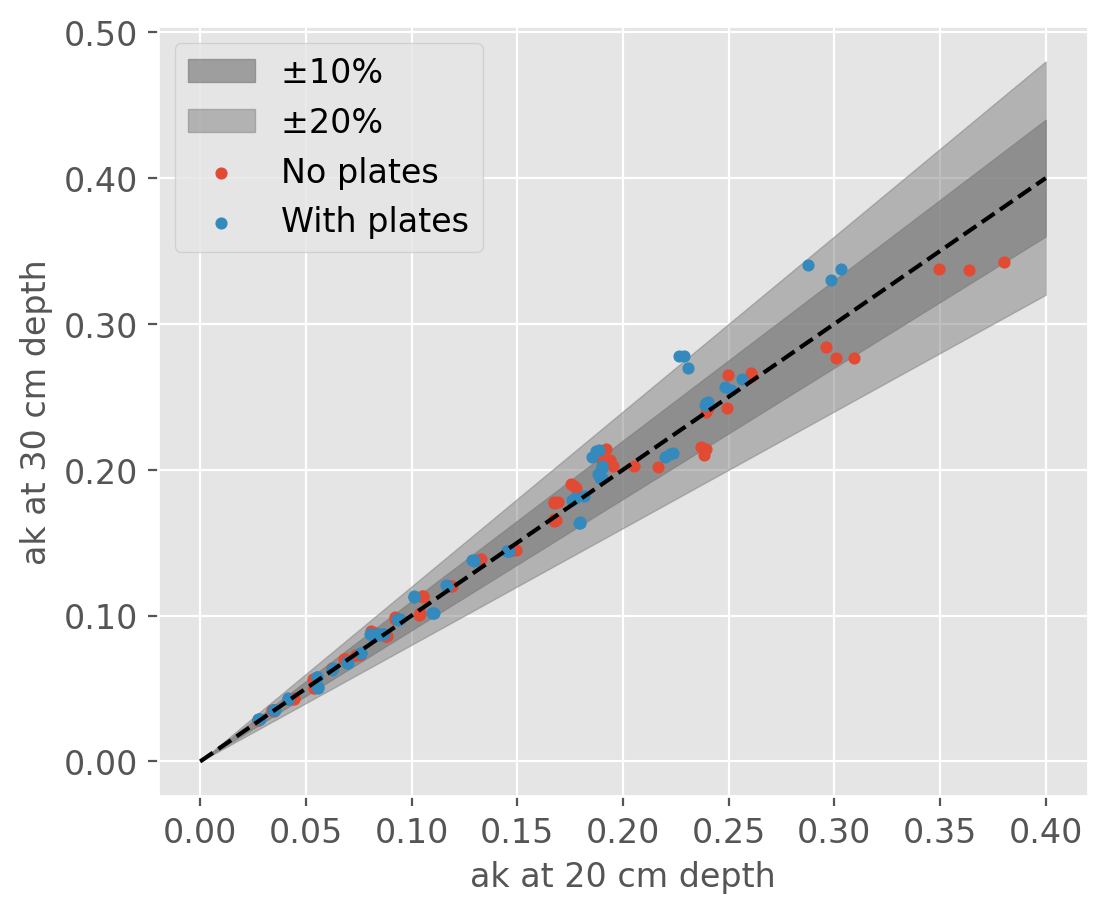

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

mx = 0.4
# 1:1 line
x = np.linspace(0, mx, 200)
y = x
ax.plot(x, y, 'k--')

# ±10% band around 1:1 line
upper = y * 1.1
lower = y * 0.9
ax.fill_between(x, lower, upper, color='gray', alpha=0.7, label='±10% ')

upper2 = y * 1.2
lower2 = y * 0.8
ax.fill_between(x, lower2, upper2, color='gray', alpha=0.5, label='±20% ')

ax.scatter(no_plates_20['ak'], no_plates_30['ak'], s=15, label='No plates')
ax.scatter(plates_20['ak'], plates_30['ak'], s=15, label='With plates')
ax.set_xlabel('ak at 20 cm depth')
ax.set_ylabel('ak at 30 cm depth')

# Only 2 decimal on axes
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))

ax.legend()

In [12]:
D_20 = 0.2
D_30 = 0.3

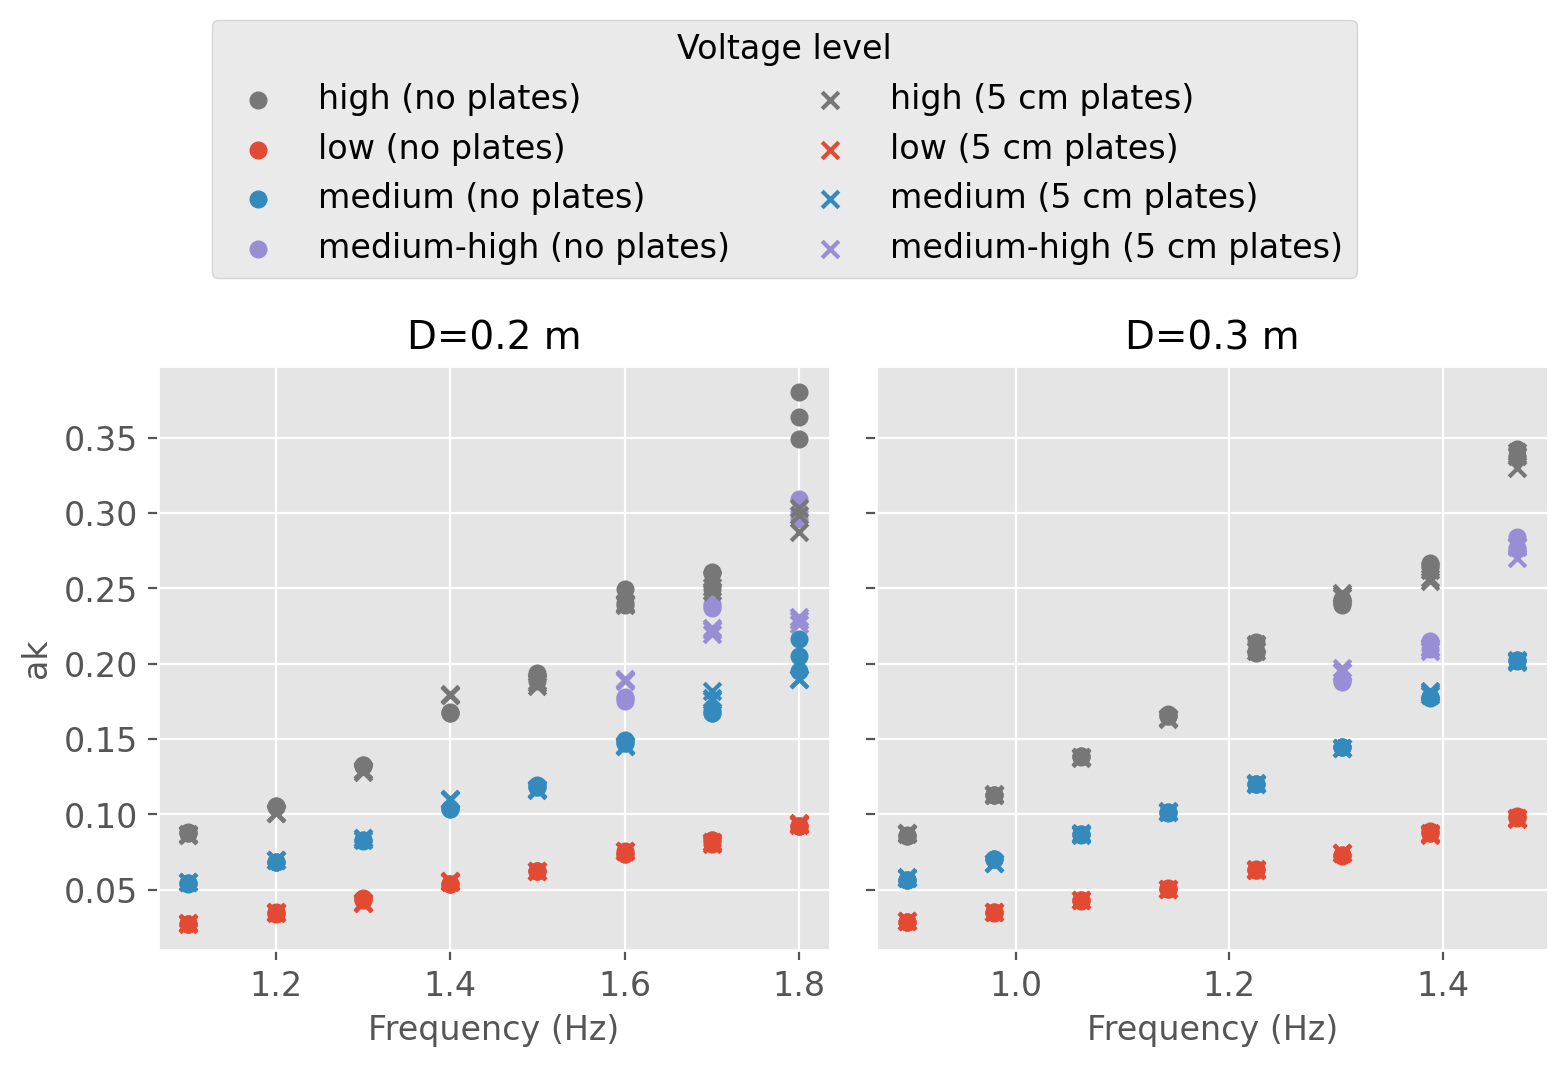

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

level_colors = {
    "low":  "C0",
    "medium":  "C1",
    "medium-high": "C2",
    "high": "C3",
}

for level, sub in no_plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["ak"],
               marker='o',
               label=f'{level} (no plates)',
               color=level_colors.get(level, "gray"))

for level, sub in plates_20.groupby("volt_level"):
    ax[0].scatter(sub["frequency"], sub["ak"],
               label=f'{level} (5 cm plates)',
               marker='x',
               color=level_colors.get(level, "gray"))
    
for level, sub in no_plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["ak"],
               marker='o',
               color=level_colors.get(level, "gray"))

for level, sub in plates_30.groupby("volt_level"):
    ax[1].scatter(sub["frequency"], sub["ak"],
               marker='x',
               color=level_colors.get(level, "gray"))


ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('ak')
ax[0].set_title(f'D={D_20} m')

ax[1].set_xlabel('Frequency (Hz)')
ax[1].set_title(f'D={D_30} m')
# Place legend below the figure
fig.legend(title='Voltage level', loc='upper center', bbox_to_anchor=(0.5, 1.35), ncol=2)
plt.tight_layout()
plt.savefig(f"/Users/kjesta/Desktop/Master prosjekt/Figurer/ak_vs_frequency.png", dpi=200, bbox_inches='tight')

In [14]:
print(no_plates_20['ak'].min())
print(plates_20['ak'].min())
print(no_plates_30['ak'].min())
print(plates_30['ak'].min())
print()
print(no_plates_20['ak'].max())
print(plates_20['ak'].max())
print(no_plates_30['ak'].max())
print(plates_30['ak'].max())

0.027491293566510693
0.02737638771091239
0.02833546623105267
0.02914627133895218

0.3802010966576637
0.3032958783437084
0.342234221779007
0.3406961159988497


In [15]:
plates_20['ak'].min()

0.02737638771091239

In [16]:
""" # Write to csv files
output_path = "/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/"
no_plates_20.to_csv(os.path.join(output_path, "no_plates_20cm.csv"), index=False)
plates_20.to_csv(os.path.join(output_path, "plates_20cm.csv"), index=False)
no_plates_30.to_csv(os.path.join(output_path, "no_plates_30cm.csv"), index=False)
plates_30.to_csv(os.path.join(output_path, "plates_30cm.csv"), index=False) """

' # Write to csv files\noutput_path = "/Users/kjesta/Desktop/LABDATA/Calculated_amps/Amps_250326/"\nno_plates_20.to_csv(os.path.join(output_path, "no_plates_20cm.csv"), index=False)\nplates_20.to_csv(os.path.join(output_path, "plates_20cm.csv"), index=False)\nno_plates_30.to_csv(os.path.join(output_path, "no_plates_30cm.csv"), index=False)\nplates_30.to_csv(os.path.join(output_path, "plates_30cm.csv"), index=False) '